# Exercise 4.13
***

In [15]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import statsmodels.api as sm
import statsmodels.formula.api as smf

from ISLP import load_data

## a)
***

In [22]:
#Loading data
Weekly = load_data('Weekly')
Weekly.head()

,Year,Lag1,Lag2,Lag3,Lag4,Lag5,Volume,Today,Direction
0,1990,0.816,1.572,-3.936,-0.229,-3.484,0.154976,-0.270,Down
1,1990,-0.270,0.816,1.572,-3.936,-0.229,0.148574,-2.576,Down
2,1990,-2.576,-0.270,0.816,1.572,-3.936,0.159837,3.514,Up
3,1990,3.514,-2.576,-0.270,0.816,1.572,0.161630,0.712,Up
4,1990,0.712,3.514,-2.576,-0.270,0.816,0.153728,1.178,Up


In [26]:
Weekly.describe()

,Year,Lag1,Lag2,Lag3,Lag4,Lag5,Volume,Today
count,1089.000000,1089.000000,1089.000000,1089.000000,1089.000000,1089.000000,1089.000000,1089.000000
mean,2000.048669,0.150585,0.151079,0.147205,0.145818,0.139893,1.574618,0.149899
std,6.033182,2.357013,2.357254,2.360502,2.360279,2.361285,1.686636,2.356927
min,1990.000000,-18.195000,-18.195000,-18.195000,-18.195000,-18.195000,0.087465,-18.195000
25%,1995.000000,-1.154000,-1.154000,-1.158000,-1.158000,-1.166000,0.332022,-1.154000
50%,2000.000000,0.241000,0.241000,0.241000,0.238000,0.234000,1.002680,0.241000
75%,2005.000000,1.405000,1.409000,1.409000,1.409000,1.405000,2.053727,1.405000
max,2010.000000,12.026000,12.026000,12.026000,12.026000,12.026000,9.328214,12.026000


In [58]:
#Correlation matrix
corr = Weekly.drop(columns = 'Direction').corr()
print(corr.round(2))

        Year  Lag1  Lag2  Lag3  Lag4  Lag5  Volume  Today
Year    1.00 -0.03 -0.03 -0.03 -0.03 -0.03    0.84  -0.03
Lag1   -0.03  1.00 -0.07  0.06 -0.07 -0.01   -0.06  -0.08
Lag2   -0.03 -0.07  1.00 -0.08  0.06 -0.07   -0.09   0.06
Lag3   -0.03  0.06 -0.08  1.00 -0.08  0.06   -0.07  -0.07
Lag4   -0.03 -0.07  0.06 -0.08  1.00 -0.08   -0.06  -0.01
Lag5   -0.03 -0.01 -0.07  0.06 -0.08  1.00   -0.06   0.01
Volume  0.84 -0.06 -0.09 -0.07 -0.06 -0.06    1.00  -0.03
Today  -0.03 -0.08  0.06 -0.07 -0.01  0.01   -0.03   1.00


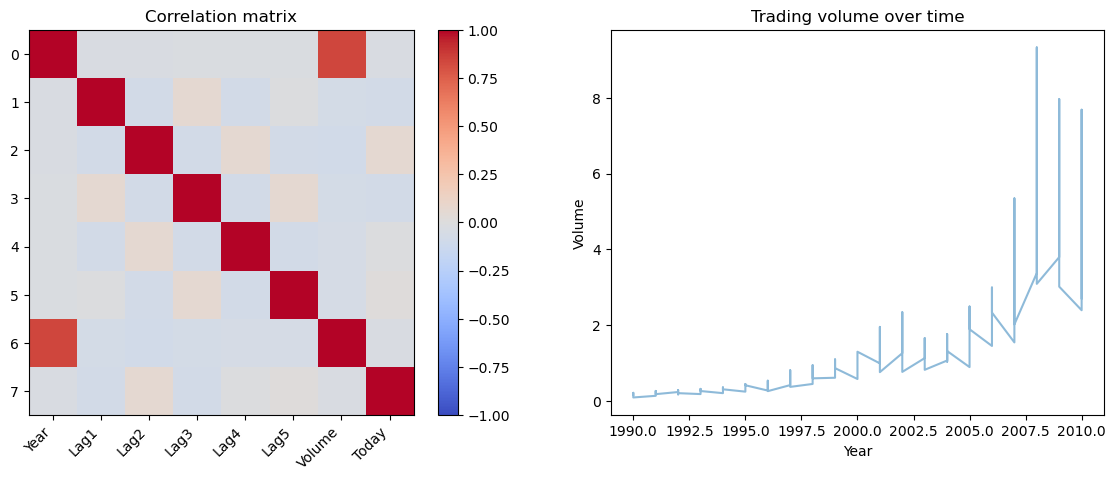

In [65]:
#Plots
fig, ax = plt.subplots(1, 2, figsize = (14, 5))

#Heatmap of correlations
im = ax[0].imshow(corr, cmap = 'coolwarm', vmin = -1, vmax = 1)

ax[0].set_xticks(range(len(corr.columns)))
ax[0].set_yticks(range(len(corr.columns)))
ax[0].set_xticklabels(corr.columns, rotation = 45, ha = 'right')
ax[0].set_xticklabels(corr.columns)
ax[0].set_title('Correlation matrix')
plt.colorbar(im, ax = ax[0])

#Volume over time
ax[1].plot(Weekly['Year'], Weekly['Volume'], alpha = 0.5)
ax[1].set_xlabel('Year')
ax[1].set_ylabel('Volume')
ax[1].set_title('Trading volume over time')

plt.tight_layout
plt.show()